## Dataset overview
- users.csv: Customer information
- orders.csv: Transaction history
- subscriptions.csv: Subscription data
- preferences.csv: Customer taste preferences
- events.scv: User behavioral events (page views, cart actions)
- voucher_application: Voucher usage data
- user_references.csv: Referral tracking
- products.csv: Product catalog

## Key Question
- Understand what are different groups among current HK customer base
- How do they differ? What are their needs? 
- What are the implications for the marketing strategy in terms of attracting similar new customers and/or retaining current customers?
- How can these insights be used to recommend QLab Tea’s next action for user growth in HK?


In [17]:
FILTER_WARNINGS = False

In [18]:
import logging
for handler in logging.root.handlers[:]:
    logging.root.removeHandler(handler)
logging.basicConfig(level=logging.DEBUG)

In [19]:
import pandas as pd
import numpy as np
import json


import matplotlib.pyplot as plt
import seaborn as sns

from collections import Counter


sns.set_style("darkgrid")
sns.set_palette("husl")
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

if FILTER_WARNINGS:
    import warnings
    warnings.filterwarnings("ignore")

plt.set_loglevel('warning')


logging.info("Setup completed successfully")
logging.debug("Using ENV variables:")
logging.debug(f"FILTER_WARNINGS: {FILTER_WARNINGS}")
logging.warning("This is a warning message.")
logging.error("This is an error message.")
logging.critical("This is a critical message.")

INFO:root:Setup completed successfully
DEBUG:root:Using ENV variables:
DEBUG:root:FILTER_WARNINGS: False
ERROR:root:This is an error message.
CRITICAL:root:This is a critical message.


In [20]:
logging.debug("Loading datasets")

try:
    users_df = pd.read_csv("./original_data/users.csv")
    orders_df = pd.read_csv("./original_data/orders.csv")
    preferences_df = pd.read_csv("./original_data/preferences.csv")

    logging.info(f"Users: {len(users_df):,} rows")
    logging.info(f"Orders: {len(orders_df):,} rows")
except FileNotFoundError as e:
    logging.error(f"Error csv not found: {e}")
    raise
except Exception as e:
    logging.critical(f"Load csv error: {e}")
    raise

DEBUG:root:Loading datasets
INFO:root:Users: 47,231 rows
INFO:root:Orders: 264,341 rows


## Data Cleaning

In [21]:
missing_values = {
    "Users": users_df.isnull().sum(),
    "Orders": orders_df.isnull().sum(),
    "Preferences": preferences_df.isnull().sum(),
}

for k, v in missing_values.items():
    logging.debug(f"{k}")
    logging.debug(f"{v}\n")

DEBUG:root:Users
DEBUG:root:id                 0
email              0
country           30
date_signed_up     0
active             0
dtype: int64

DEBUG:root:Orders
DEBUG:root:order_items                  0
shipping_postal_code       362
shipping_date               85
discounts                    0
subscription_id         142937
user_id                     13
id                           0
currency                     0
total_incl_tax               0
total_excl_tax               0
shipping_incl_tax            0
shipping_method              0
shipping_code                0
status                       0
date_placed                  0
dtype: int64

DEBUG:root:Preferences
DEBUG:root:user_id           0
intensity         0
taste_profile     0
brewing_method    0
created           0
updated           0
dtype: int64



### Clean Orders (Keeping only HKD orders)

In [22]:
conversion_rate = {
    "SGD": 1.0,
    "HKD": 0.17,
    "MYR": 0.31,
}


orders_clean_df = orders_df.copy()
logging.debug(f"Original rows: {len(orders_clean_df)}")
# Only keep completed orders
orders_clean_df = orders_clean_df[orders_clean_df["status"].isin(["Shipped", "Complete"])]
logging.debug(f"After filtering for completed orders: {len(orders_clean_df)}")
# Remove <=0 order totals
orders_clean_df = orders_clean_df[orders_clean_df["total_incl_tax"]>0]
logging.debug(f"Remove potentially order_totals<=0: {len(orders_clean_df)}")
# Remove all users that are not from HK
orders_clean_df = orders_clean_df[orders_clean_df["currency"]=="HKD"]
logging.debug(f"Filter currency HK: {len(orders_clean_df)}")

# Fix dates
# Remove the microseconds part to standardize the format (irrelevant to our analysis)
orders_clean_df["date_placed"] = orders_clean_df["date_placed"].str.extract(r'(\d{4}-\d{2}-\d{2} \d{2}:\d{2}:\d{2})')

# Convert to proper datetime
orders_clean_df["date_placed"] = pd.to_datetime(orders_clean_df["date_placed"], errors='coerce')

# Convert to epoch time (seconds since 1970-01-01)
orders_clean_df["date_placed_epoch"] = orders_clean_df["date_placed"].astype('int64') // 10**9
logging.debug(f"After fixing datetime: {len(orders_clean_df)}")

orders_clean_df = orders_clean_df.dropna(subset=["date_placed", "user_id"])
logging.debug(f"Drop na: {len(orders_clean_df)}")

logging.debug(f"Cleaned orders: {len(orders_clean_df):,} rows")
logging.debug(f"Date range: {orders_clean_df['date_placed'].min()} - {orders_clean_df['date_placed'].max()}")
logging.debug(f"Total revenue: {orders_clean_df['total_incl_tax'].sum():.3f}")

def parse_order_items(order_items_json):
    try:
        items = json.loads(order_items_json)
        num_items = sum(int(item.get("quantity", 1)) for item in items)
        product_ids = [item.get("product_id") for item in items]
        return pd.Series({
            "num_items": num_items,
            "product_ids": product_ids
        })
    except:
        return pd.Series({"num_items": 1, "product_ids": []})
    
order_items_parsed = orders_clean_df['order_items'].apply(parse_order_items)
orders_clean_df = pd.concat([orders_clean_df, order_items_parsed], axis=1)

orders_clean_df["total_incl_tax_sgd"] = (
    orders_clean_df["total_incl_tax"]
    * orders_clean_df["currency"].map(conversion_rate)
)

logging.debug("Order items parsing done")
logging.info(f"Average item per order: {orders_clean_df['num_items'].mean():.2f}")
logging.debug(f"Final number of rows: {len(orders_clean_df)}")
logging.debug(f"Unique user ids: {orders_clean_df['user_id'].nunique()}")
display(orders_clean_df.head())

del orders_df

DEBUG:root:Original rows: 264341
DEBUG:root:After filtering for completed orders: 221340
DEBUG:root:Remove potentially order_totals<=0: 214851
DEBUG:root:Filter currency HK: 81
DEBUG:root:After fixing datetime: 81
DEBUG:root:Drop na: 81
DEBUG:root:Cleaned orders: 81 rows
DEBUG:root:Date range: 2020-03-18 03:29:23 - 2022-09-05 12:05:36
DEBUG:root:Total revenue: 29603.910
DEBUG:root:Order items parsing done
INFO:root:Average item per order: 2.51
DEBUG:root:Final number of rows: 81
DEBUG:root:Unique user ids: 40


,order_items,shipping_postal_code,shipping_date,discounts,subscription_id,user_id,id,currency,total_incl_tax,total_excl_tax,shipping_incl_tax,shipping_method,shipping_code,status,date_placed,date_placed_epoch,num_items,product_ids,total_incl_tax_sgd
143202,"[{""line_price_before_discounts_excl_tax"": ""84....",NaN,2020-03-19,"[{""category"": ""Basket"", ""offer_id"": 15, ""offer...",NaN,112544.0,254490,HKD,102.00,102.00,0.00,Janio Hong Kong,janio_hong_kong,Complete,2020-03-18 03:29:23,1584502,2,"[4383, 3606]",17.3400
144774,"[{""line_price_before_discounts_excl_tax"": ""84....",NaN,2020-03-30,"[{""category"": ""Basket"", ""offer_id"": 8, ""offer_...",NaN,112792.0,256413,HKD,168.00,168.00,0.00,Janio Hong Kong,janio_hong_kong,Complete,2020-03-29 13:27:45,1585488,3,"[3593, 4463, 3963]",28.5600
144775,"[{""line_price_before_discounts_excl_tax"": ""84....",NaN,2020-04-28,[],13144.0,112792.0,256414,HKD,117.93,117.93,33.93,Janio Hong Kong,janio_hong_kong,Complete,2020-04-27 16:00:00,1588003,1,[3963],20.0481
145365,"[{""line_price_before_discounts_excl_tax"": ""65....",NaN,2020-04-03,[],NaN,112544.0,257125,HKD,163.93,163.93,33.93,Janio Hong Kong,janio_hong_kong,Complete,2020-04-02 01:40:44,1585791,2,"[3588, 3624]",27.8681
146432,"[{""line_price_before_discounts_excl_tax"": ""84....",NaN,2020-04-07,[],NaN,94044.0,258357,HKD,440.26,440.26,164.26,Janio Hong Kong,janio_hong_kong,Complete,2020-04-06 03:06:48,1586142,3,"[4924, 3953, 4664]",74.8442


### Note
- Why are there only around 40 HK customers?
- Can we even do data analysis on a dataset of this size? Will the result even be reliable?
- We can attempt a simple RFM model

### Clean Users (Keeping only HKD users)

In [23]:
users_clean_df = users_df.copy()

users_clean_df = users_clean_df[users_clean_df["id"].isin(orders_clean_df["user_id"])]
logging.debug(f"Number of users: {len(users_clean_df)}")
display(users_clean_df.head())

del users_df

DEBUG:root:Number of users: 40


,id,email,country,date_signed_up,active
7546,94044,xxxx@hotmail.com,Hong Kong,2021-07-21,No
26029,112544,xxxx@gmail.com,Hong Kong,2020-03-18,No
26277,112792,xxxx@gmail.com,Hong Kong,2020-03-26,No
28669,115185,xxxx@gmail.com,Hong Kong,2020-04-23,No
28947,115463,xxxx@gmail.com,Hong Kong,2020-04-26,No


In [24]:
preferences_clean_df = preferences_df.copy()
preferences_clean_df = preferences_df.dropna(subset=["user_id"])
del preferences_df

## Feature Engineering

#### Time-Dependent RFM definition
- recency_days = (reference_date - max(order_date))
- frequency_orders = count of orders of a customer / (max(order_date)-min(order_date))
- monetary_total = weighted sum of total_incl_tax_sgd (weight is based on year, 2020: 0.2, 2021: 0.5, 2022: 0.8, 2023: 1.0)

In [25]:
newest_date = orders_clean_df["date_placed"].max()
oldest_date = orders_clean_df["date_placed"].min()

logging.debug(f"Reference date: {newest_date}")

def arbitrary_date_weights(dates):
    year = dates.dt.year
    return np.select(
        [year <= 2020, year <= 2021, year <= 2022],
        [0.2, 0.5, 0.8],
        default=1.0,
    )

orders_clean_df["monetary_weight"] = arbitrary_date_weights(orders_clean_df["date_placed"])

orders_clean_df["weighted_total_incl_tax_sgd"] = (
    orders_clean_df["total_incl_tax_sgd"] * orders_clean_df["monetary_weight"]
)

rfm_features = orders_clean_df.groupby("user_id").agg(
    {
        "date_placed": [
            lambda x: (newest_date - x.max()).days,                     # Recency
            lambda x: len(x) / max((x.max() - x.min()).days, 1)         # Frequency
        ],
        "weighted_total_incl_tax_sgd": "sum" # Monetary
    }
).reset_index()

rfm_features.columns = ["user_id", "recency_days", "frequency_orders", "monetary_total"]

order_counts = orders_clean_df.groupby("user_id")["id"].count().rename("order_count")
rfm_features = rfm_features.join(order_counts, on="user_id")


logging.debug(f"\n{rfm_features.describe()}")
display(rfm_features.tail())

DEBUG:root:Reference date: 2022-09-05 12:05:36
DEBUG:root:
             user_id  recency_days  frequency_orders  monetary_total  \
count      40.000000     40.000000         40.000000       40.000000   
mean   125263.700000    443.375000          0.825834       57.685016   
std      7626.881021    247.676349          0.528731       57.953115   
min     94044.000000      0.000000          0.011696        1.428000   
25%    123293.500000    291.000000          0.288462       19.743460   
50%    126453.500000    424.000000          1.000000       41.072850   
75%    130488.750000    621.250000          1.000000       70.853025   
max    133617.000000    886.000000          2.000000      303.343920   

       order_count  
count    40.000000  
mean      2.025000  
std       2.423046  
min       1.000000  
25%       1.000000  
50%       1.000000  
75%       2.000000  
max      14.000000  


,user_id,recency_days,frequency_orders,monetary_total,order_count
35,132507.0,155,1.0,7.344,1
36,132774.0,124,1.0,70.720,1
37,133427.0,36,1.0,93.432,1
38,133593.0,0,1.0,59.568,1
39,133617.0,10,1.0,11.424,1


#### Preferences and Taste

In [26]:
def jsonlist_column_count(df, json_column_name):
    """
    Count number of occurences of items in json_column_name column of a df
    """
    
    def count_list_items(json_str):
        """Helper function to count items in JSON list"""
        try:
            json_list = json.loads(json_str)
            if isinstance(json_list, list):
                # Convert all items to strings to ensure they can be used as column names
                return Counter(str(item) for item in json_list if item != "None")
            else:
                return Counter()
        except (json.JSONDecodeError, TypeError):
            return Counter()
    
    counters = df[json_column_name].apply(count_list_items)
    
    # Get all unique items
    all_items = set()
    for counter in counters:
        all_items.update(counter.keys())
    
    # Create new DataFrame
    count_data = {}
    for item in sorted(all_items):
        count_data[item] = [counter.get(item, 0) for counter in counters]
    
    return pd.DataFrame(count_data)

def group_taste_profiles(df):
    taste_profile_grouping = {
        "sweets": ["Caramel", "Chocolate"],
        "fruits": ["Berries", "Citrus Lemons", "Stone Fruits"],
        "flower": ["Edible Flowers",],
    }

    for group_name, tastes in taste_profile_grouping.items():
        df[group_name] = df[tastes].max(axis=1)

    return df


taste_features = jsonlist_column_count(preferences_clean_df, "taste_profile")
taste_features = group_taste_profiles(taste_features)
taste_features = pd.concat([preferences_clean_df["user_id"], taste_features], axis=1)


display(taste_features.tail())

,user_id,Berries,Caramel,Chocolate,Citrus Lemons,Edible Flowers,Stone Fruits,sweets,fruits,flower
19884,103927,0,0,1,0,0,0,1,0,0
19885,103925,0,0,0,0,0,0,0,0,0
19886,103924,0,0,1,1,0,0,1,1,0
19887,103919,1,1,1,0,0,0,1,1,0
19888,103917,1,0,0,1,1,0,0,1,1


#### Combine features

In [27]:
customer_features = rfm_features.copy()
customer_features = customer_features.merge(taste_features, on="user_id", how="left", )
pref_cols = taste_features.columns.drop('user_id')  # Exclude the join key
customer_features[pref_cols] = customer_features[pref_cols].fillna(0)
display(customer_features)

,user_id,recency_days,frequency_orders,monetary_total,order_count,Berries,Caramel,Chocolate,Citrus Lemons,Edible Flowers,Stone Fruits,sweets,fruits,flower
0,94044.0,882,1.000000,14.96884,1,1.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,1.0
1,112544.0,886,0.142857,9.04162,2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,112792.0,391,0.028112,195.77727,14,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,115185.0,732,0.039683,46.06456,5,1.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0
4,115463.0,831,0.066667,11.12514,2,1.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0
5,118536.0,816,1.000000,13.54084,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6,119215.0,811,1.000000,36.93216,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7,119684.0,511,0.090909,27.81285,2,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
8,120866.0,714,0.049180,23.06628,3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9,122770.0,699,1.000000,1.42800,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## Interpretation

### RFM model
1. Ternary model
2. Binary model

In [28]:
def rank_based_rfm(df):
    
    df['R_Score'] = pd.qcut(df['recency_days'], q=3, labels=[3, 2, 1], duplicates='drop')
    # Use rank-based approach to handle frequency
    df['F_Score'] = pd.qcut(df['frequency_orders'].rank(method='first'), q=3, labels=[1, 2, 3])
    df['M_Score'] = pd.qcut(df['monetary_total'], q=3, labels=[1, 2, 3], duplicates='drop')
    
    # Create RFM score
    df['RFM_Score'] = df['R_Score'].astype(str) + df['F_Score'].astype(str) + df['M_Score'].astype(str)
    
    segment_map = {
        # R=3 (Most Recent), F=3 (Most Frequent), M=3 (Highest Value) - best
        '333': 'Champions',
        '332': 'Loyal Champions', 
        '331': 'Regular Champions',
        '323': 'Recent Loyal',
        '322': 'Core Loyal',
        '321': 'Developing Loyal',
        '313': 'Recent Big Spenders',
        '312': 'Recent Medium Spenders', 
        '311': 'Recent Customers',
        
        # R=2 (Medium Recency) - need attention
        '233': 'At-Risk Champions',
        '232': 'At-Risk Loyal',
        '231': 'At-Risk Regulars',
        '223': 'Slipping Big Spenders',
        '222': 'Average Customers',
        '221': 'Slipping Low-Value',
        '213': 'Occasional Big Spenders',
        '212': 'Occasional Medium Spenders',
        '211': 'Occasional Low-Spenders',
        
        # R=1 (Least Recent) - worst
        '133': 'Dormant Big Spenders',
        '132': 'Dormant Medium Spenders',
        '131': 'Dormant Customers',
        '123': 'Inactive Loyal',
        '122': 'Inactive Regulars',
        '121': 'Inactive Trialists',
        '113': 'Lost Big Spenders',
        '112': 'Lost Medium Spenders',
        '111': 'Lost Customers'
    }
    
    df['Segment'] = df['RFM_Score'].map(segment_map).fillna('Others')
    return df

# Apply
df = rank_based_rfm(customer_features.copy())
logging.info(f"\n{df['Segment'].value_counts()}")
display(df[["user_id", "Segment", "RFM_Score"]].head(15))

INFO:root:
Segment
Lost Customers                5
Inactive Trialists            5
Champions                     5
Occasional Big Spenders       4
Loyal Champions               4
Average Customers             3
Lost Medium Spenders          2
Regular Champions             2
Occasional Low-Spenders       1
Inactive Regulars             1
At-Risk Loyal                 1
Slipping Low-Value            1
Occasional Medium Spenders    1
Slipping Big Spenders         1
Recent Big Spenders           1
At-Risk Champions             1
Core Loyal                    1
Recent Loyal                  1
Name: count, dtype: int64


,user_id,Segment,RFM_Score
0,94044.0,Lost Customers,111
1,112544.0,Lost Customers,111
2,112792.0,Occasional Big Spenders,213
3,115185.0,Lost Medium Spenders,112
4,115463.0,Lost Customers,111
5,118536.0,Lost Customers,111
6,119215.0,Lost Medium Spenders,112
7,119684.0,Occasional Low-Spenders,211
8,120866.0,Lost Customers,111
9,122770.0,Inactive Trialists,121


In [29]:
RECENCY_THRESHOLD = 200 # around half a year

def binary_rfm(df):
    """
    Binary RFM scoring where:
    1 = Good, 0 = Bad
    Higher score = Better customer
    """
    # Calculate medians for binary splits
    recency_median = df['recency_days'].median()
    frequency_median = df['frequency_orders'].median()
    monetary_median = df['monetary_total'].median()
    
    logging.debug(f"Medians - Recency: {recency_median:.1f} days, Frequency: {frequency_median:.3f}, Monetary: ${monetary_median:.2f}")
    
    # Binary scoring (1 = Good, 0 = Bad)
    df['R_Score_binary'] = (df['recency_days'] < RECENCY_THRESHOLD).astype(int)  # 1 = Recent, 0 = Not recent
    df['F_Score_binary'] = (df['frequency_orders'] > frequency_median).astype(int)  # 1 = Frequent, 0 = Infrequent
    df['M_Score_binary'] = (df['monetary_total'] > monetary_median).astype(int)  # 1 = High value, 0 = Low value
    
    # Create binary RFM score
    df['RFM_Score_binary'] = df['R_Score_binary'].astype(str) + df['F_Score_binary'].astype(str) + df['M_Score_binary'].astype(str)
    
    # Binary segment map
    segment_map_binary = {
        '111': 'VIP Elite',
        '110': 'Loyal Core', 
        '101': 'High-Potential New',
        '100': 'Emerging Customers',
        '011': 'At-Risk VIP',
        '010': 'Loyal but Declining',
        '001': 'High-Value Inactive',
        '000': 'Dormant Base'
    }

    action_map_binary = {
        '111': 'Retain and Grow',
        '110': 'Increase Value', 
        '101': 'Build Frequency',
        '100': 'Nurture and Convert',
        '011': 'Win-Back Priority',
        '010': 'Re-engagement',
        '001': 'Targeted Win-Back',
        '000': 'Minimal Effort'
    }
    
    df['Segment_binary'] = df['RFM_Score_binary'].map(segment_map_binary)
    df['Segment_binary_action'] = df["RFM_Score_binary"].map(segment_map_binary)
    
    return df

df_binary = binary_rfm(customer_features.copy())
logging.info(f"\n{df_binary['Segment_binary'].value_counts().sort_index()}")

DEBUG:root:Medians - Recency: 424.0 days, Frequency: 1.000, Monetary: $41.07
INFO:root:
Segment_binary
At-Risk VIP             3
Dormant Base           18
Emerging Customers      2
High-Potential New      6
High-Value Inactive    11
Name: count, dtype: int64


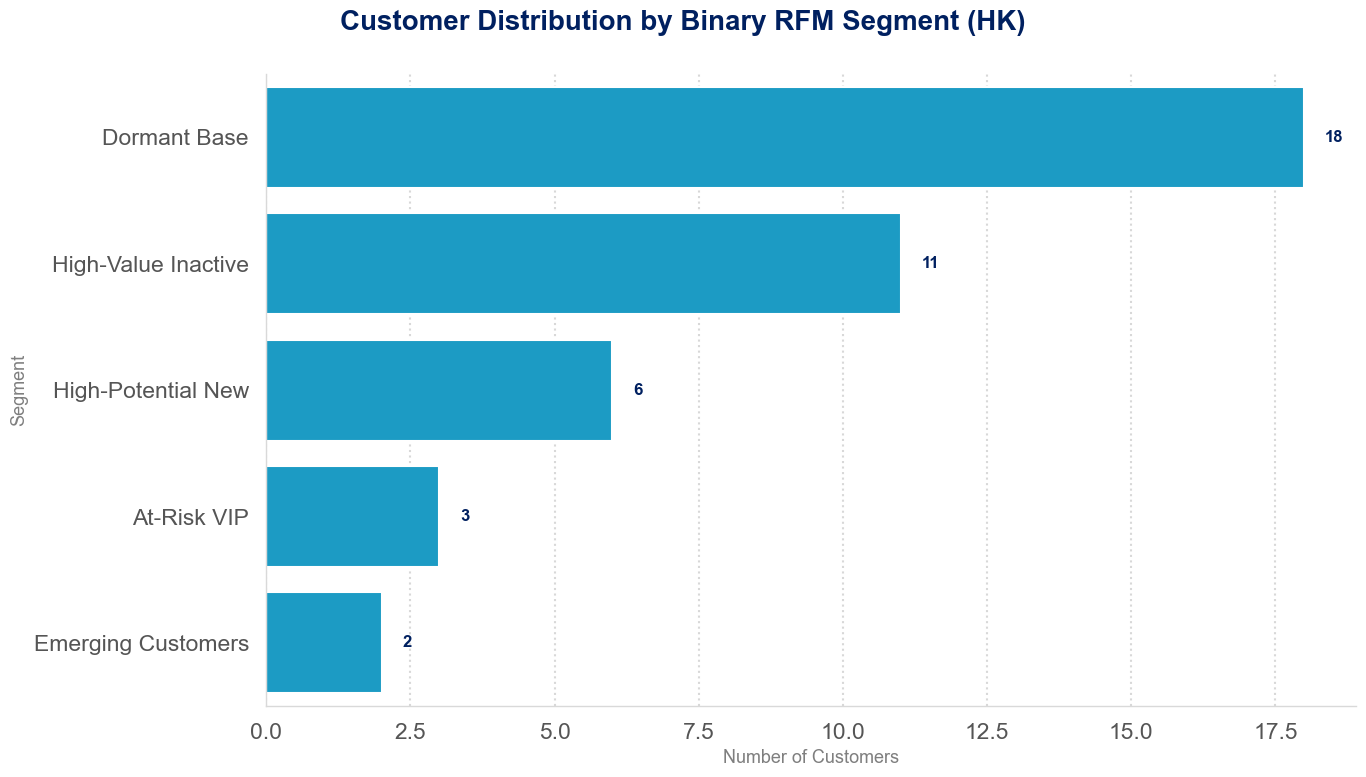

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

def set_mckinsey_style():
    plt.rcParams['font.family'] = 'sans-serif'
    plt.rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans', 'Liberation Sans']
    global MCK_BLUE, MCK_LIGHT_BLUE, MCK_GREY, MCK_ACCENT
    MCK_BLUE = '#002060'       # 深蓝 (Core/Singapore)
    MCK_LIGHT_BLUE = '#00A9E0' # 亮蓝 (Growth/Malaysia)
    MCK_GREY = '#7F7F7F'       # 灰色 (辅助/Passive)
    MCK_ACCENT = '#E4002B'     # 红色 (重点/Highlight)

    sns.set_context("talk")
    sns.set_style("white")
    plt.rcParams['axes.edgecolor'] = '#d9d9d9'
    plt.rcParams['axes.linewidth'] = 1
    plt.rcParams['xtick.color'] = '#555555'
    plt.rcParams['ytick.color'] = '#555555'
    plt.rcParams['text.color'] = '#333333'
    plt.rcParams['axes.labelcolor'] = '#333333'
    plt.rcParams['axes.titleweight'] = 'bold'
    plt.rcParams['axes.titlesize'] = 16
    plt.rcParams['axes.labelsize'] = 12

set_mckinsey_style()

# 1. 统计各分群的客户数量，并按数量降序排列
segment_counts = df_binary['Segment_binary'].value_counts().sort_values(ascending=False)

# 2. 设置画布大小
fig = plt.figure(figsize=(14, 8))
ax = plt.gca()

# 3. 绘制水平条形图 (Horizontal Bar Plot)
plot = sns.barplot(y=segment_counts.index, x=segment_counts.values, color=MCK_LIGHT_BLUE, ax=ax)

# 4. 添加图表标题和轴标签
plt.suptitle('Customer Distribution by Binary RFM Segment (HK)', 
             fontsize=20, fontweight='bold', color=MCK_BLUE, y=0.98)
plt.xlabel('Number of Customers', fontsize=13, color=MCK_GREY, fontweight='normal')
plt.ylabel('Segment', fontsize=13, color=MCK_GREY, fontweight='normal')

# 5. 在每个柱子末尾标注具体数值
for i, v in enumerate(segment_counts.values):
    plt.text(v + (max(segment_counts.values)*0.02), i, str(v), 
             va='center', fontsize=12, color=MCK_BLUE, fontweight='bold')

# 6. 移除顶部和右侧边框，保持专业简洁风格
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(True, axis='x', linestyle=':', alpha=0.3, color=MCK_GREY)

# 7. 调整布局并显示
plt.tight_layout()
plt.show()

## Note
- A simple interpretation may still be worth it for HK market
- Maybe include some basic preference data of these users and see if we can get a suggestion for what type of tea to push for

In [31]:
df_binary_cleaned = df_binary[(df_binary[["sweets", "fruits", "flower"]].any(axis=1))]
logging.info(f"\n{df_binary_cleaned['Segment_binary'].value_counts().sort_index()}")
display(df_binary_cleaned[["user_id", "monetary_total", "Segment_binary", "sweets", "fruits", "flower"]])

INFO:root:
Segment_binary
At-Risk VIP            1
Dormant Base           4
Emerging Customers     2
High-Potential New     2
High-Value Inactive    3
Name: count, dtype: int64


,user_id,monetary_total,Segment_binary,sweets,fruits,flower
0,94044.0,14.96884,Dormant Base,1.0,1.0,1.0
3,115185.0,46.06456,High-Value Inactive,1.0,1.0,0.0
4,115463.0,11.12514,Dormant Base,1.0,1.0,0.0
7,119684.0,27.81285,Dormant Base,1.0,0.0,0.0
16,125384.0,44.13285,At-Risk VIP,1.0,1.0,1.0
20,126465.0,37.14500,Dormant Base,1.0,0.0,0.0
21,126726.0,50.67785,High-Value Inactive,1.0,1.0,0.0
24,128186.0,79.81500,High-Value Inactive,1.0,1.0,0.0
25,128296.0,303.34392,High-Potential New,1.0,1.0,0.0
34,132446.0,58.44736,High-Potential New,0.0,1.0,0.0


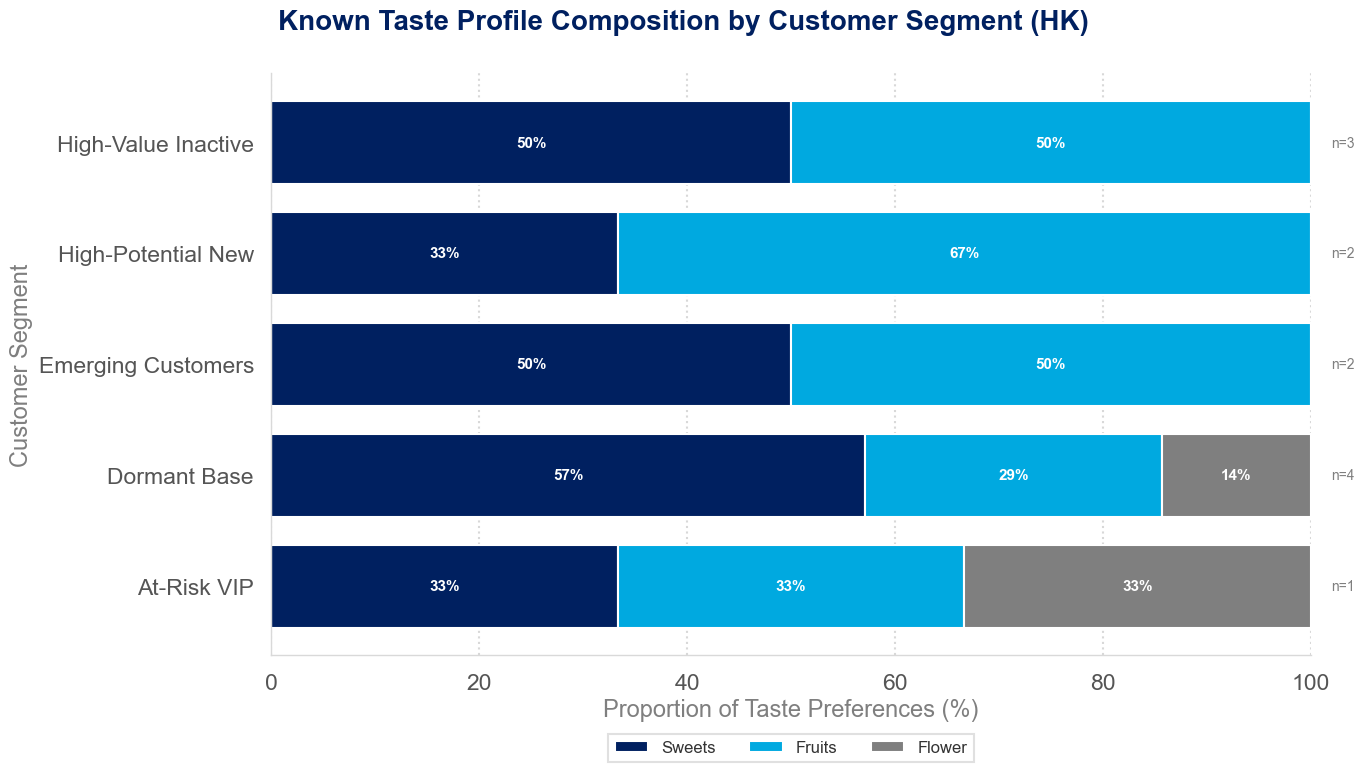

In [32]:
set_mckinsey_style()

# Calculate the sum of preferences for each segment
taste_by_segment = df_binary_cleaned.groupby('Segment_binary')[['sweets', 'fruits', 'flower']].sum()

# Calculate proportional percentages (sums to 100% per segment)
taste_percentages = taste_by_segment.div(taste_by_segment.sum(axis=1), axis=0) * 100

# Sort by segment name
taste_percentages = taste_percentages.sort_index()

# Get segment sizes for annotation
segment_totals = df_binary_cleaned.groupby('Segment_binary').size()

fig, ax = plt.subplots(figsize=(14, 8))

# Create horizontal stacked bar chart
taste_percentages.plot(kind='barh', stacked=True, ax=ax,
                       color=[MCK_BLUE, MCK_LIGHT_BLUE, MCK_GREY],
                       width=0.75, edgecolor='white', linewidth=1.5)

# Add percentage labels on each segment
for i, segment in enumerate(taste_percentages.index):
    cumulative = 0
    for taste in ['sweets', 'fruits', 'flower']:
        value = taste_percentages.loc[segment, taste]
        if value > 8:  # Only show label if segment is large enough
            ax.text(cumulative + value/2, i, f'{value:.0f}%',
                   ha='center', va='center', fontsize=11, 
                   color='white', fontweight='bold')
        cumulative += value

# Styling
plt.suptitle('Known Taste Profile Composition by Customer Segment (HK)', 
             fontsize=20, fontweight='bold', color=MCK_BLUE, y=0.98)
ax.set_xlabel('Proportion of Taste Preferences (%)', fontsize=17, color=MCK_GREY)
ax.set_ylabel('Customer Segment', fontsize=17, color=MCK_GREY)
ax.set_xlim(0, 100)

# Add sample size annotation
for i, segment in enumerate(taste_percentages.index):
    n = segment_totals[segment]
    ax.text(102, i, f'n={n}', va='center', fontsize=10, color=MCK_GREY)

# Legend - positioned next to x-axis label at bottom center
ax.legend(['Sweets', 'Fruits', 'Flower'], 
          loc='upper center', bbox_to_anchor=(0.5, -0.12), 
          ncol=3, frameon=True, 
          fancybox=False, edgecolor='#d9d9d9', fontsize=12)

# Remove spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(True, axis='x', linestyle=':', alpha=0.3, color=MCK_GREY)

plt.tight_layout()
plt.show()